<a href="https://colab.research.google.com/github/PraveenkkumarNS/Assignment-AIML/blob/main/multi_home_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
path = kagglehub.dataset_download("arslanali4343/real-estate-dataset")

100%|██████████| 11.7k/11.7k [00:00<00:00, 17.3MB/s]

Extracting files...


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get coefficients from the trained Logistic Regression model
feature_coefficients_logistic = logistic_model.coef_[0]

# Get feature names from the training data
feature_names = X_train_cls.columns

# Create a DataFrame for better visualization
importance_df_logistic = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_coefficients_logistic
})

# Sort by absolute importance for better understanding of influence
importance_df_logistic['Absolute Importance'] = importance_df_logistic['Importance'].abs()
importance_df_logistic = importance_df_logistic.sort_values(by='Absolute Importance', ascending=False)

print("Feature Importance (Coefficients) for Logistic Regression:")
display(importance_df_logistic.drop(columns=['Absolute Importance']))

Feature Importance (Coefficients) for Logistic Regression:


,Feature,Importance
5,RM,2.134759
3,CHAS,1.049717
7,DIS,-0.506268
10,PTRATIO,-0.350470
4,NOX,-0.313334
12,LSTAT,-0.147941
8,RAD,0.142501
0,CRIM,-0.110312
6,AGE,-0.036759
1,ZN,0.016353


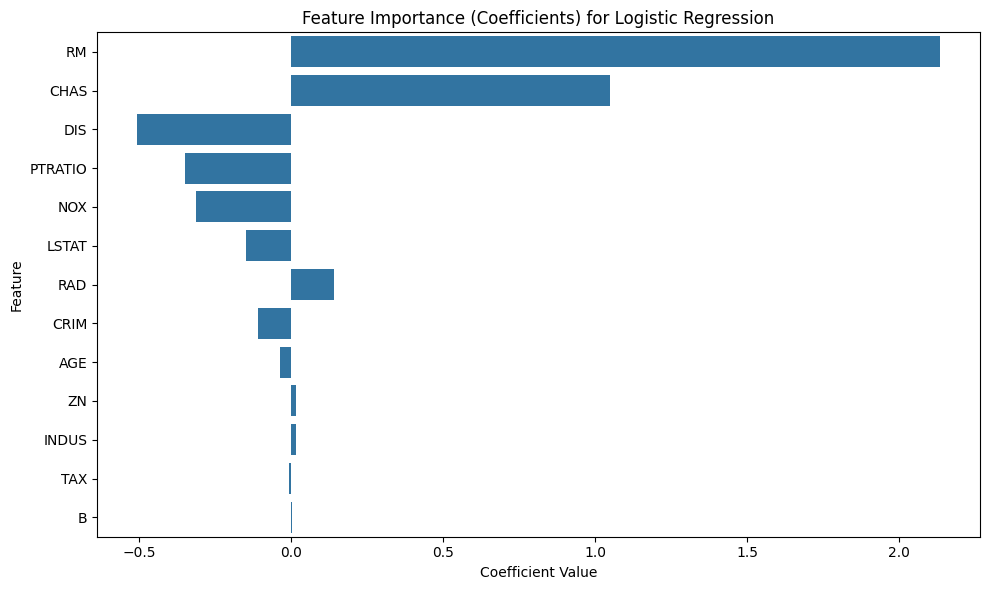

In [18]:
# Create a bar plot for feature importances (coefficients)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_logistic)
plt.title('Feature Importance (Coefficients) for Logistic Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Decision Tree Regressor
feature_importances_dt = dt_regressor.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df_dt = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances_dt
})

# Sort by importance in descending order
importance_df_dt = importance_df_dt.sort_values(by='Importance', ascending=False)

print("Feature Importance for Decision Tree Regressor:")
display(importance_df_dt)

Feature Importance for Decision Tree Regressor:


,Feature,Importance
5,RM,0.568739
12,LSTAT,0.197707
7,DIS,0.070742
10,PTRATIO,0.049953
4,NOX,0.041673
0,CRIM,0.026232
2,INDUS,0.013682
11,B,0.011562
9,TAX,0.010559
6,AGE,0.006839


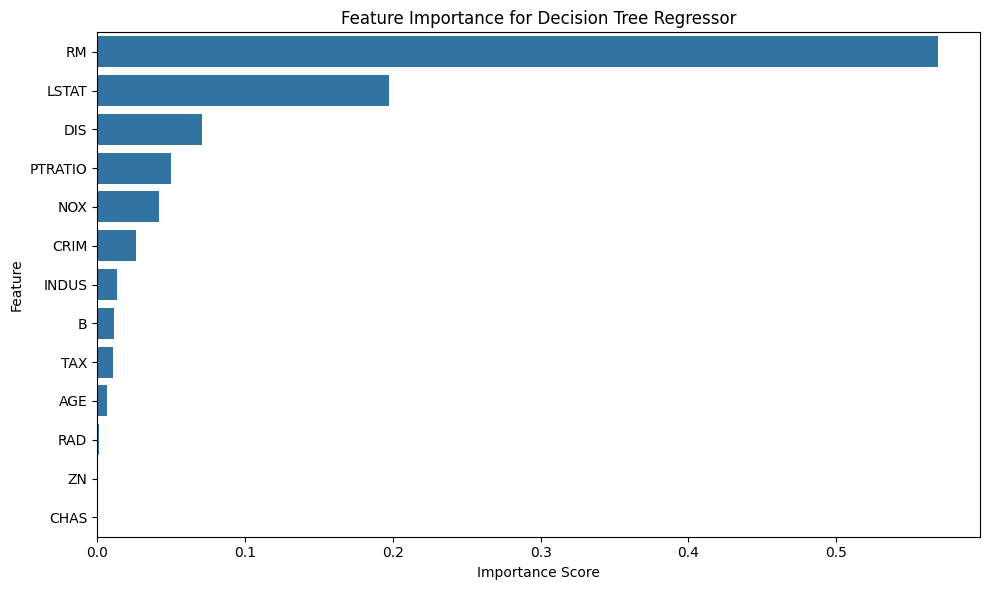

In [16]:
# Create a bar plot for feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_dt)
plt.title('Feature Importance for Decision Tree Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

Linear Regression - Mean Squared Error: 71.22
Linear Regression - R-squared: 0.17


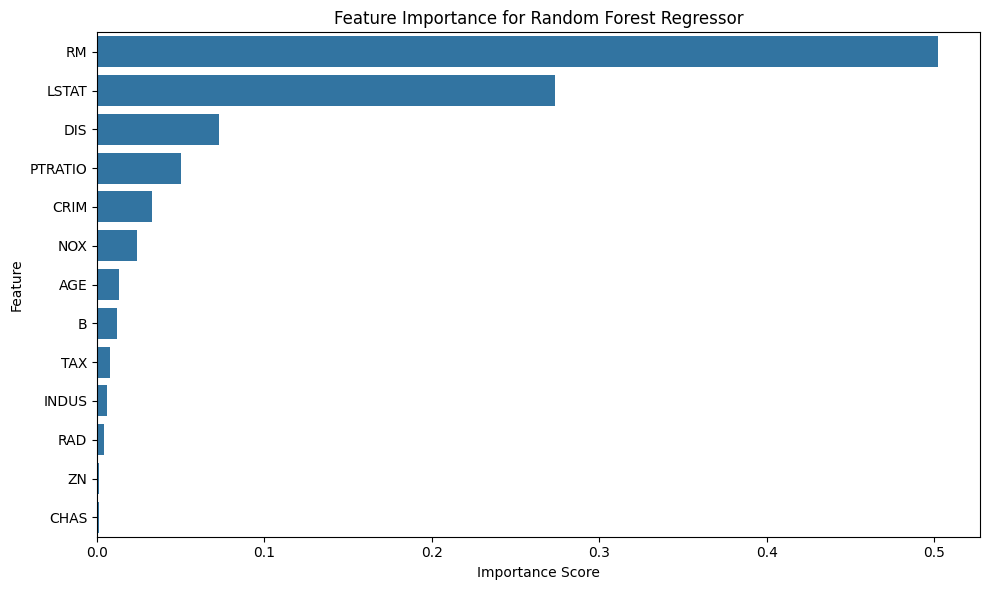

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a bar plot for feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Feature Importance for Random Forest Regressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [12]:
import pandas as pd

# Get feature importances from the trained Random Forest Regressor
feature_importances = rf_regressor.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance for Random Forest Regressor:")
display(importance_df)

Feature Importance for Random Forest Regressor:


,Feature,Importance
5,RM,0.502338
12,LSTAT,0.273619
7,DIS,0.072644
10,PTRATIO,0.050114
0,CRIM,0.032970
4,NOX,0.023805
6,AGE,0.013154
11,B,0.011766
9,TAX,0.007533
2,INDUS,0.005956


In [11]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Random Forest for Regression (using original continuous MEDV target)
rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X_train, y_train)
y_pred_rf_reg = rf_regressor.predict(X_test)

mse_rf_reg = mean_squared_error(y_test, y_pred_rf_reg)
r2_rf_reg = r2_score(y_test, y_pred_rf_reg)

print(f"Random Forest Regressor - Mean Squared Error: {mse_rf_reg:.2f}")
print(f"Random Forest Regressor - R-squared: {r2_rf_reg:.2f}")

# Random Forest for Classification (using binned MEDV target)
rf_classifier = RandomForestClassifier(random_state=42)
rf_classifier.fit(X_train_cls, y_train_cls)
y_pred_rf_cls = rf_classifier.predict(X_test_cls)

accuracy_rf_cls = accuracy_score(y_test_cls, y_pred_rf_cls)
precision_rf_cls = precision_score(y_test_cls, y_pred_rf_cls)
recall_rf_cls = recall_score(y_test_cls, y_pred_rf_cls)
f1_rf_cls = f1_score(y_test_cls, y_pred_rf_cls)
roc_auc_rf_cls = roc_auc_score(y_test_cls, rf_classifier.predict_proba(X_test_cls)[:, 1])

print(f"Random Forest Classifier - Accuracy: {accuracy_rf_cls:.2f}")
print(f"Random Forest Classifier - Precision: {precision_rf_cls:.2f}")
print(f"Random Forest Classifier - Recall: {recall_rf_cls:.2f}")
print(f"Random Forest Classifier - F1-Score: {f1_rf_cls:.2f}")
print(f"Random Forest Classifier - ROC AUC Score: {roc_auc_rf_cls:.2f}")

Random Forest Regressor - Mean Squared Error: 28.70
Random Forest Regressor - R-squared: 0.67
Random Forest Classifier - Accuracy: 0.78
Random Forest Classifier - Precision: 0.71
Random Forest Classifier - Recall: 0.82
Random Forest Classifier - F1-Score: 0.76
Random Forest Classifier - ROC AUC Score: 0.92


In [10]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

# Decision Tree for Regression (using original continuous MEDV target)
dt_regressor = DecisionTreeRegressor(random_state=42)
dt_regressor.fit(X_train, y_train)
y_pred_dt_reg = dt_regressor.predict(X_test)

mse_dt_reg = mean_squared_error(y_test, y_pred_dt_reg)
r2_dt_reg = r2_score(y_test, y_pred_dt_reg)

print(f"Decision Tree Regressor - Mean Squared Error: {mse_dt_reg:.2f}")
print(f"Decision Tree Regressor - R-squared: {r2_dt_reg:.2f}")

# Decision Tree for Classification (using binned MEDV target)
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_cls, y_train_cls)
y_pred_dt_cls = dt_classifier.predict(X_test_cls)

accuracy_dt_cls = accuracy_score(y_test_cls, y_pred_dt_cls)
precision_dt_cls = precision_score(y_test_cls, y_pred_dt_cls)
recall_dt_cls = recall_score(y_test_cls, y_pred_dt_cls)
f1_dt_cls = f1_score(y_test_cls, y_pred_dt_cls)
roc_auc_dt_cls = roc_auc_score(y_test_cls, dt_classifier.predict_proba(X_test_cls)[:, 1])

print(f"Decision Tree Classifier - Accuracy: {accuracy_dt_cls:.2f}")
print(f"Decision Tree Classifier - Precision: {precision_dt_cls:.2f}")
print(f"Decision Tree Classifier - Recall: {recall_dt_cls:.2f}")
print(f"Decision Tree Classifier - F1-Score: {f1_dt_cls:.2f}")
print(f"Decision Tree Classifier - ROC AUC Score: {roc_auc_dt_cls:.2f}")

Decision Tree Regressor - Mean Squared Error: 36.03
Decision Tree Regressor - R-squared: 0.58
Decision Tree Classifier - Accuracy: 0.81
Decision Tree Classifier - Precision: 0.73
Decision Tree Classifier - Recall: 0.89
Decision Tree Classifier - F1-Score: 0.80
Decision Tree Classifier - ROC AUC Score: 0.82


In [9]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
# For simplicity, we'll use a multi_class strategy, though Logistic Regression is typically for classification.
# Given the target variable 'MEDV' is continuous, a direct application of Logistic Regression isn't standard.
# If the intent was a classification task, 'MEDV' would need to be binned.
# As the original request specified training Logistic Regression with the given datasets, I will proceed with a classification approach by binning 'MEDV'.
# Let's create a binary target for demonstration purposes: prices above median vs. below/equal to median.
median_medv = df['MEDV'].median()
y_classified = (df['MEDV'] > median_medv).astype(int)

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X, y_classified, test_size=0.2, random_state=42)

logistic_model = LogisticRegression(max_iter=1000, solver='liblinear') # Increased max_iter for convergence
logistic_model.fit(X_train_cls, y_train_cls)

# Make predictions on the test set
y_pred_logistic = logistic_model.predict(X_test_cls)

# Evaluate the model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy_logistic = accuracy_score(y_test_cls, y_pred_logistic)
precision_logistic = precision_score(y_test_cls, y_pred_logistic)
recall_logistic = recall_score(y_test_cls, y_pred_logistic)
f1_logistic = f1_score(y_test_cls, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test_cls, logistic_model.predict_proba(X_test_cls)[:, 1])

print(f"Logistic Regression - Accuracy: {accuracy_logistic:.2f}")
print(f"Logistic Regression - Precision: {precision_logistic:.2f}")
print(f"Logistic Regression - Recall: {recall_logistic:.2f}")
print(f"Logistic Regression - F1-Score: {f1_logistic:.2f}")
print(f"Logistic Regression - ROC AUC Score: {roc_auc_logistic:.2f}")

Logistic Regression - Accuracy: 0.80
Logistic Regression - Precision: 0.74
Logistic Regression - Recall: 0.82
Logistic Regression - F1-Score: 0.78
Logistic Regression - ROC AUC Score: 0.89


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_linear = linear_model.predict(X_test)

# Evaluate the model
mse_linear = mean_squared_error(y_test, y_pred_linear)
r2_linear = r2_score(y_test, y_pred_linear)

print(f"Linear Regression - Mean Squared Error: {mse_linear:.2f}")
print(f"Linear Regression - R-squared: {r2_linear:.2f}")

Linear Regression - Mean Squared Error: 71.22
Linear Regression - R-squared: 0.17


In [7]:
from sklearn.model_selection import train_test_split

X = df.drop('MEDV', axis=1)  # Features
y = df['MEDV']              # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (408, 13)
Shape of X_test: (103, 13)
Shape of y_train: (408,)
Shape of y_test: (103,)


In [6]:
df['RM'] = df['RM'].fillna(df['RM'].mean())
print(df.isnull().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [4]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     511 non-null    float64
 1   ZN       511 non-null    float64
 2   INDUS    511 non-null    float64
 3   CHAS     511 non-null    int64  
 4   NOX      511 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      511 non-null    float64
 7   DIS      511 non-null    float64
 8   RAD      511 non-null    int64  
 9   TAX      511 non-null    int64  
 10  PTRATIO  511 non-null    float64
 11  B        511 non-null    float64
 12  LSTAT    511 non-null    float64
 13  MEDV     511 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 56.0 KB
None
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         5
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64


In [3]:
import pandas as pd

df = pd.read_csv(os.path.join(path, 'data.csv'))

print(df.head())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  MEDV  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  


In [2]:
import os
print(os.listdir(path))

['data.csv']
